In [17]:
import pandas as pd
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.ROOT, {'font.size': 12}])
from matplotlib import colors

In [18]:
basedir = "/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017"

In [19]:
os.listdir(basedir)

['output_all_templates_5f_tau21p25.pkl',
 'fit_tau21p40_all_renormalized',
 'output_all_templates_3f_tau21p30_renormalized.pkl',
 'output_all_templates_3f_tau21p25_renormalized.pkl',
 'output_all_templates_3f_tau21p20.pkl',
 'output_all_templates_3f_inclusive.pkl',
 'fit_tau21p20_all_renormalized',
 'fit_tau21p35_all_renormalized',
 'output_all_templates_3f_tau21p30.pkl',
 'output_all_templates_3f_inclusive_renormalized.pkl',
 'output_all_templates_3f_tau21p30_fit_variable_reweighed.pkl',
 'output_all.coffea',
 'output_all_templates_5f_inclusive_renormalized.pkl',
 'output_all_templates_3f_tau21p35_renormalized.pkl',
 'output_all_templates_3f_tau21p20_renormalized.pkl',
 'output_all_templates_5f_tau21p40.pkl',
 'fit_tau21p30_all_fit_variable_reweighed',
 'v1',
 'output_all_templates_3f_tau21p40_renormalized.pkl',
 'output_all_templates_5f_tau21p35.pkl',
 'fit_tau21p25_all_renormalized',
 'logs',
 'fit_tau21p30_all_renormalized',
 'old',
 'v2_toDavide',
 'output_all_templates_3f_tau21p2

In [20]:
tau_inclusive = f"{basedir}/fit_inclusive_all_renormalized/results"
tau_cut = f"{basedir}/fit_tau21p%1_all_renormalized/results"
tau_p30_reweighed = f"{basedir}/fit_tau21p30_all_fit_variable_reweighed/results"

In [21]:
AK8Taggers_bb = ['btagDDBvLV2', 'particleNetMD_Xbb_QCD', 'deepTagMD_ZHbbvsQCD', 'btagHbb']
AK8Taggers_cc = ['btagDDCvLV2', 'particleNetMD_Xcc_QCD', 'deepTagMD_ZHccvsQCD']
#tau21s = ["0.20", "0.25","0.30", "0.35", "0.40"]
tau21s = ["0.40", "0.35","0.30", "0.25", "0.20"]
wps  = [ "L","M","H"]
pts = ["450to500","500to600", "600toInf"]

In [22]:
results = []
missing_fits = []

In [23]:
for tagger in AK8Taggers_cc:
    for wp in wps:
        for pt in pts:
            file = f"{tau_inclusive}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
            if not os.path.exists(file):
                missing_fits.append(file)
                continue
            #print(file)
            df = pd.read_csv(file, sep=",")
            results.append({
                            "SF_flavour": "c",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": df["c+cc"].values[0],
                            "SF_errUp": df["c+ccErrUp"].values[0],
                            "SF_errDown": df["c+ccErrDown"].values[0],
                            "tau21": 1,
                            "reweighed": 0
                            })
#loop on tau21
for tagger in AK8Taggers_cc:
    for wp in wps:
        for pt in pts:
            for tau21 in tau21s:
                file = f"{tau_cut.replace('%1', tau21[2:])}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
                if not os.path.exists(file):
                    missing_fits.append(file)
                    continue
                #print(file)
                df = pd.read_csv(file, sep=",")
                results.append({
                                "SF_flavour": "c",
                                "tagger": tagger,
                                "wp": wp,
                                "pt": pt,
                                "SF": df["c+cc"].values[0],
                                "SF_errUp": df["c+ccErrUp"].values[0],
                                "SF_errDown": df["c+ccErrDown"].values[0],
                                "tau21": tau21,
                                "reweighed": 0
                                })

for tagger in AK8Taggers_cc:
    for wp in wps:
        for pt in pts:
            file = f"{tau_p30_reweighed}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
            if not os.path.exists(file):
                missing_fits.append(file)
                continue
            #print(file)
            df = pd.read_csv(file, sep=",")
            results.append({
                            "SF_flavour": "c",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": df["c+cc"].values[0],
                            "SF_errUp": df["c+ccErrUp"].values[0],
                            "SF_errDown": df["c+ccErrDown"].values[0],
                            "tau21": 0.3,
                            "reweighed": 1
                            })
            
for tagger in AK8Taggers_bb:
    for wp in wps:
        for pt in pts:
            file = f"{tau_inclusive}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
            if not os.path.exists(file):
                missing_fits.append(file)
                continue
            #print(file)
            df = pd.read_csv(file, sep=",")
            results.append({
                            "SF_flavour": "b",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": df["b+bb"].values[0],
                            "SF_errUp": df["b+bbErrUp"].values[0],
                            "SF_errDown": df["b+bbErrDown"].values[0],
                            "tau21": 1,
                            "reweighed": 0
                            })
            
for tagger in AK8Taggers_bb:
    for wp in wps:
        for pt in pts:
            for tau21 in tau21s:
                file = f"{tau_cut.replace('%1', tau21[2:])}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
                if not os.path.exists(file):
                    missing_fits.append(file)
                    continue
                #print(file)
                df = pd.read_csv(file, sep=",")
                results.append({
                                "SF_flavour": "b",
                                "tagger": tagger,
                                "wp": wp,
                                "pt": pt,
                                "SF": df["b+bb"].values[0],
                                "SF_errUp": df["b+bbErrUp"].values[0],
                                "SF_errDown": df["b+bbErrDown"].values[0],
                                "tau21": tau21,
                                "reweighed": 0
                                })

for tagger in AK8Taggers_bb:
    for wp in wps:
        for pt in pts:
            file = f"{tau_p30_reweighed}/fitResults_msd40{tagger}{wp}wp_Pt-{pt}.csv"
            if not os.path.exists(file):
                missing_fits.append(file)
                continue
            #print(file)
            df = pd.read_csv(file, sep=",")
            results.append({
                            "SF_flavour": "b",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": df["b+bb"].values[0],
                            "SF_errUp": df["b+bbErrUp"].values[0],
                            "SF_errDown": df["b+bbErrDown"].values[0],
                            "tau21": 0.3,
                            "reweighed": 1
                            })


In [24]:
sf_results = pd.DataFrame(results)
sf_results

,SF_flavour,tagger,wp,pt,SF,SF_errUp,SF_errDown,tau21,reweighed
0,c,btagDDCvLV2,L,450to500,0.716126,0.050825,0.045082,1,0
1,c,btagDDCvLV2,L,500to600,0.658808,0.074254,0.061012,1,0
2,c,btagDDCvLV2,L,600toInf,0.595401,0.090026,0.075404,1,0
3,c,btagDDCvLV2,M,450to500,0.672032,0.063666,0.057815,1,0
4,c,btagDDCvLV2,M,500to600,0.620236,0.084369,0.086823,1,0
...,...,...,...,...,...,...,...,...,...
433,b,btagHbb,M,500to600,0.925367,0.032706,0.030355,0.3,1
434,b,btagHbb,M,600toInf,0.885173,0.040938,0.037891,0.3,1
435,b,btagHbb,H,450to500,0.866407,0.026832,0.030634,0.3,1
436,b,btagHbb,H,500to600,0.813220,0.036008,0.034387,0.3,1


In [25]:
missing_fits

['/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017/fit_tau21p25_all_renormalized/results/fitResults_msd40particleNetMD_Xcc_QCDMwp_Pt-450to500.csv',
 '/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017/fit_tau21p25_all_renormalized/results/fitResults_msd40btagHbbMwp_Pt-600toInf.csv',
 '/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017/fit_tau21p20_all_renormalized/results/fitResults_msd40btagHbbMwp_Pt-600toInf.csv']

In [26]:
np.arange(7)

array([0, 1, 2, 3, 4, 5, 6])

In [27]:
results_tau21_uncertainty = []

missing fit


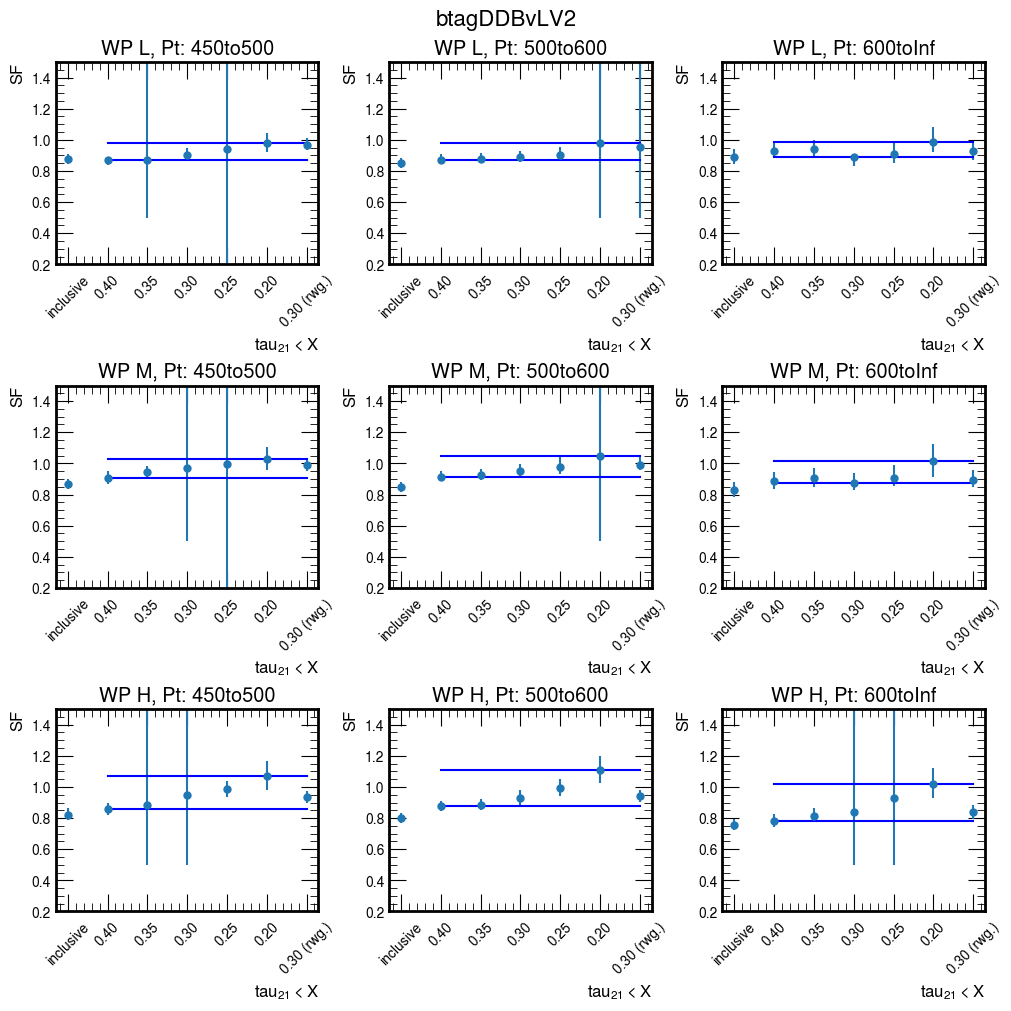

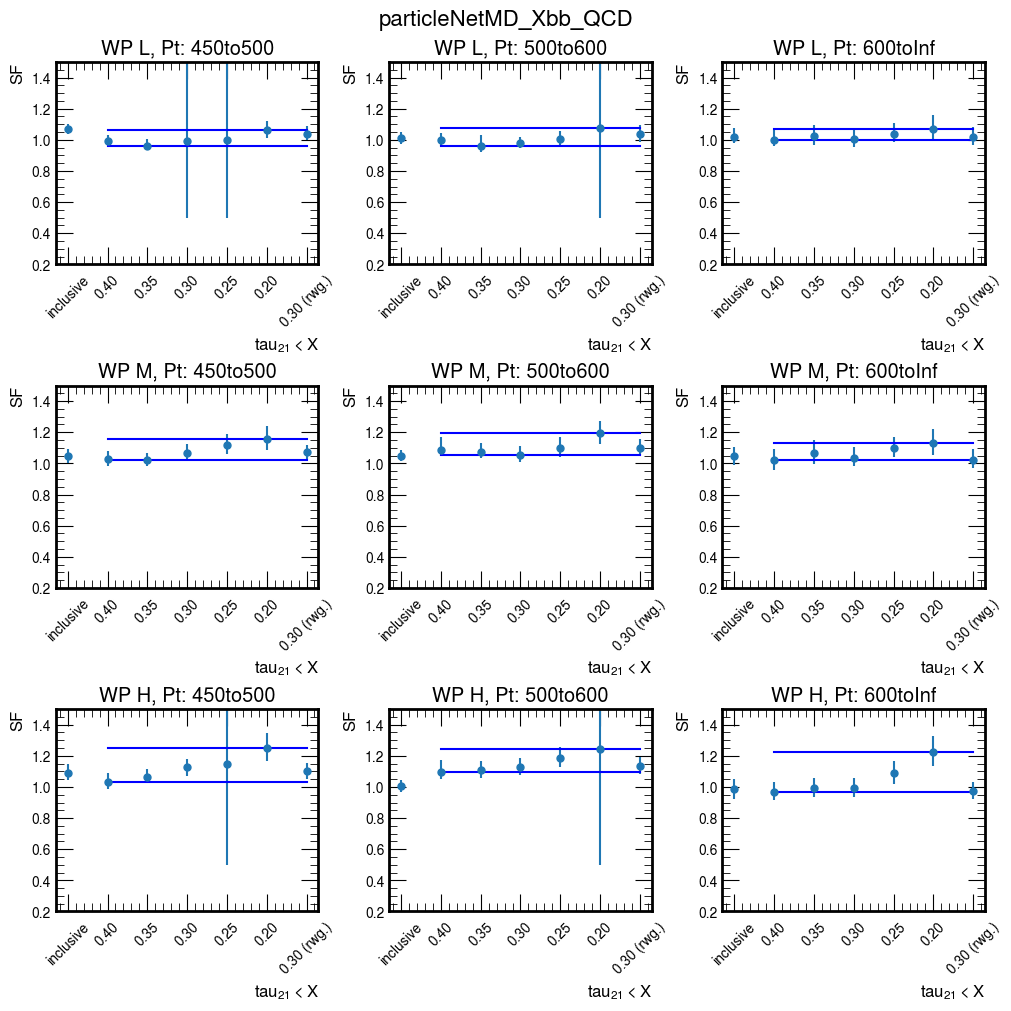

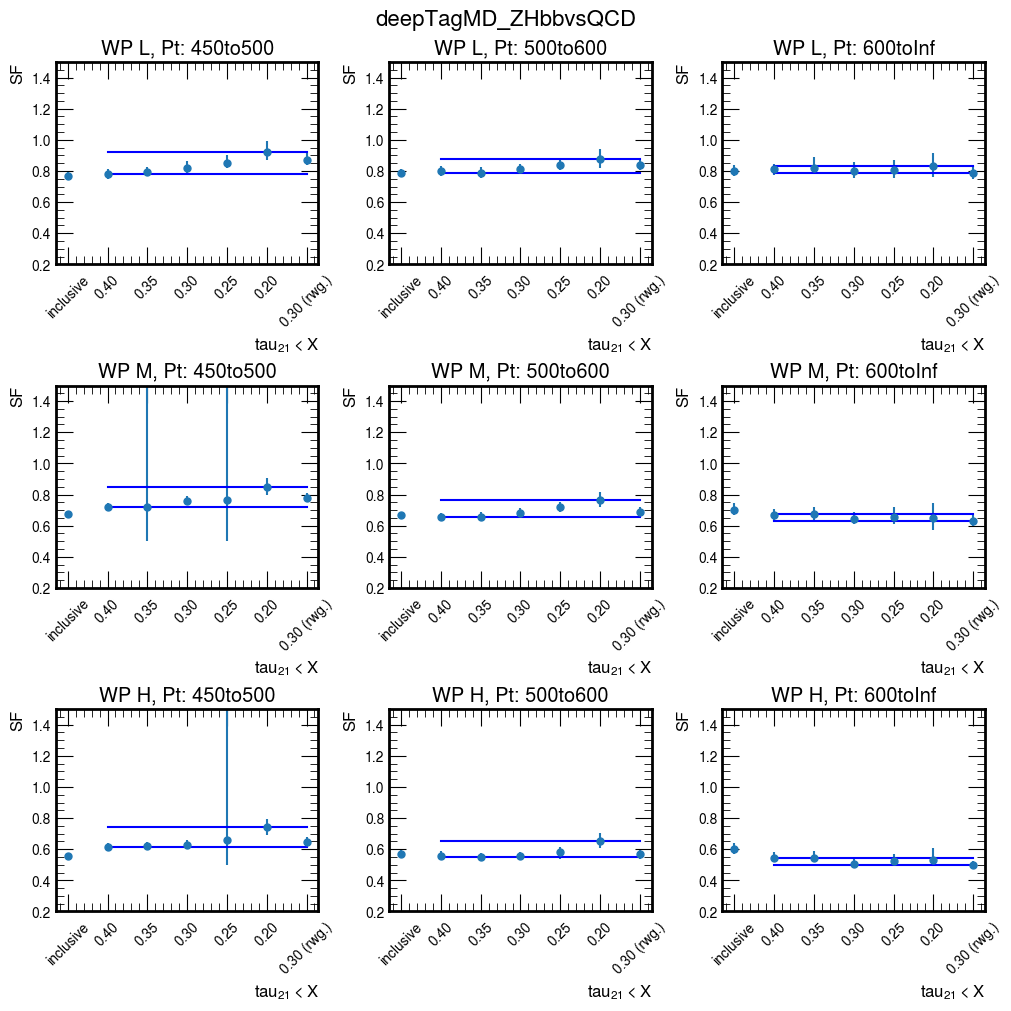

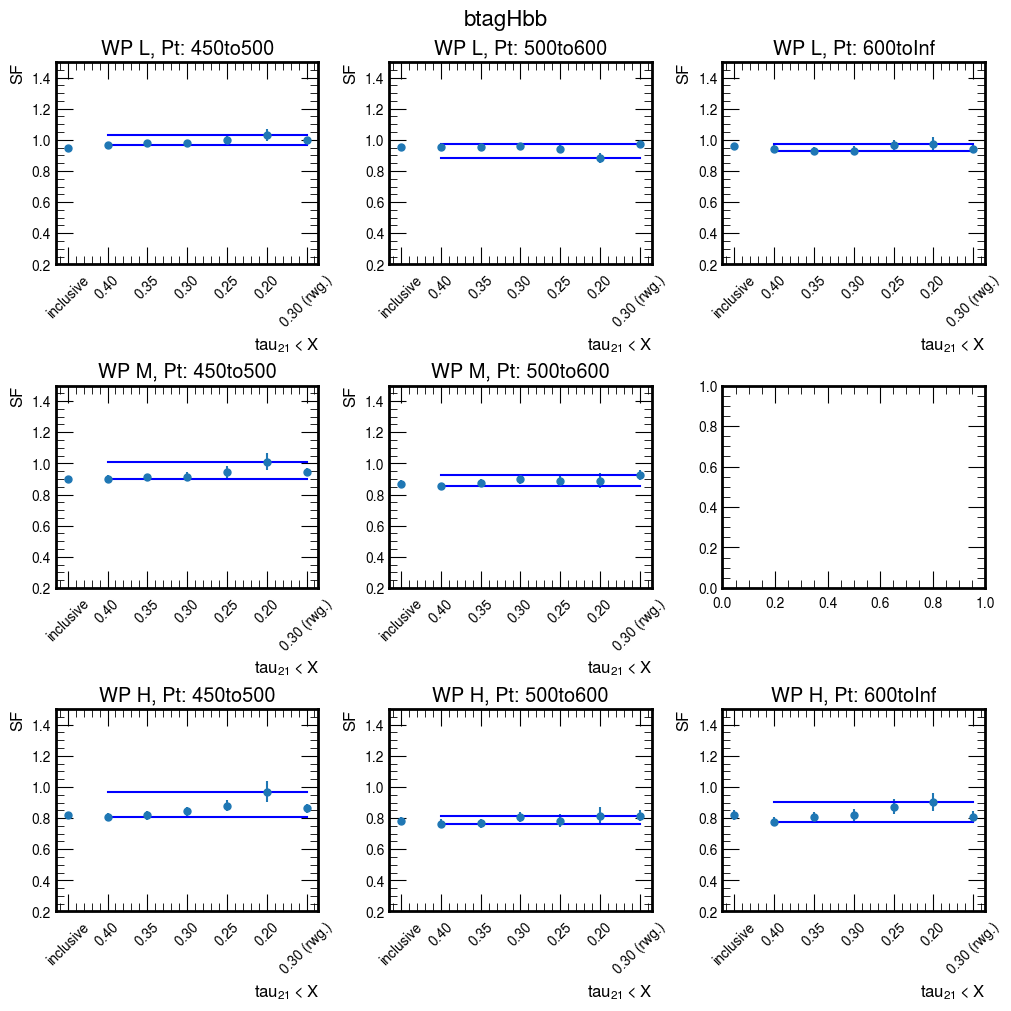

In [30]:
for tagger in AK8Taggers_bb:
    f, axs = plt.subplots(3,3,figsize=(10,10), constrained_layout=True, dpi=100)
    #plt.subplots_adjust(wspace=0.2, hspace=0.2)
    f.suptitle(tagger, fontsize=16)
    for ix, wp in enumerate(wps):
        for iy, pt in enumerate(pts):
            sfdata = sf_results[(sf_results.SF_flavour=="b")&\
                                (sf_results.tagger==tagger)&\
                                (sf_results.wp==wp)&\
                                (sf_results.pt==pt)]
            
            sf_max = sfdata[sfdata.tau21!=1].SF.max()
            sf_min = sfdata[sfdata.tau21!=1].SF.min()
            
            if len(sfdata)<7:
                print("missing fit")
                continue
                
            sf_rew = sfdata[sfdata.reweighed==1].SF.values[0]
            sf_rew_unc = abs(sfdata[sfdata.tau21=="0.30"].SF.values[0] - sf_rew)
                
            results_tau21_uncertainty.append({
                            "SF_flavour": "b",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": sfdata[sfdata.tau21=="0.30"].SF.values[0],
                            "SF_errUp": sfdata[sfdata.tau21=="0.30"]["SF_errUp"].values[0],
                            "SF_errDown": sfdata[sfdata.tau21=="0.30"]["SF_errDown"].values[0],
                            "tau21_uncertainty": abs(sf_max-sf_min)/2,
                            "reweighting_uncertainty": sf_rew_unc,
                            })
            
            ax = axs[ix, iy]
            ax.set_title(f"WP {wp}, Pt: {pt}")
            ax.set_xlabel("$tau_{21}< X$")
            ax.set_ylabel("SF")
            #print(np.arange(5), sfdata.SF)
            ax.errorbar(np.arange(7), sfdata.SF.values, yerr=[sfdata.SF_errDown.values, sfdata.SF_errUp.values]
                        , linestyle='', marker='o', markersize=5, label=wp)
            ax.set_ylim(0.2, 1.5)
            xticklabels = list(map(str,sfdata.tau21.values))
            xticklabels[0] = "inclusive"
            xticklabels[-1] = "0.30 (rwg.)"
            ax.set_xticks(np.arange(7), xticklabels, rotation=45)
            
            ax.plot([1., 6.], [sf_max,sf_max], "b-")
            ax.plot([1., 6.], [sf_min,sf_min], "b-")
    plt.savefig(f"results_2017_{tagger}.png", dpi=300, format="png")

missing fit


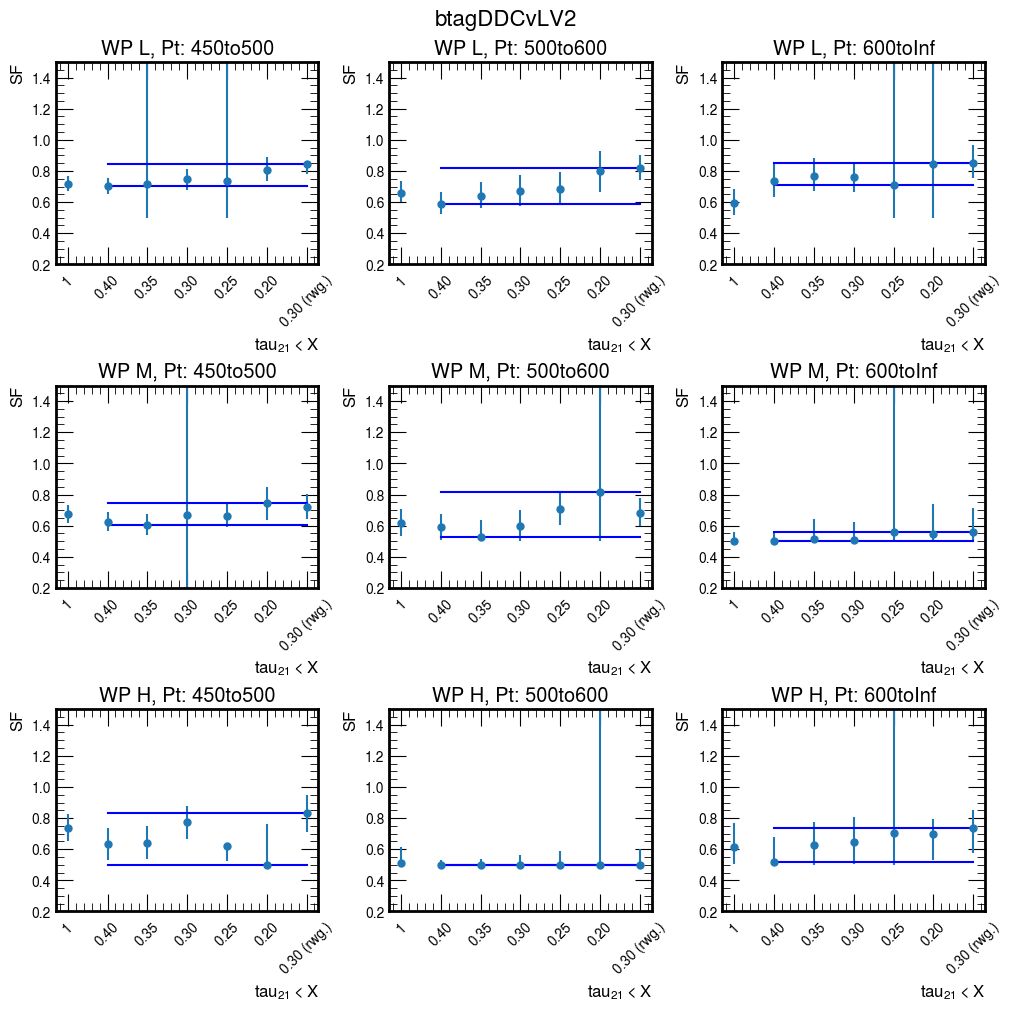

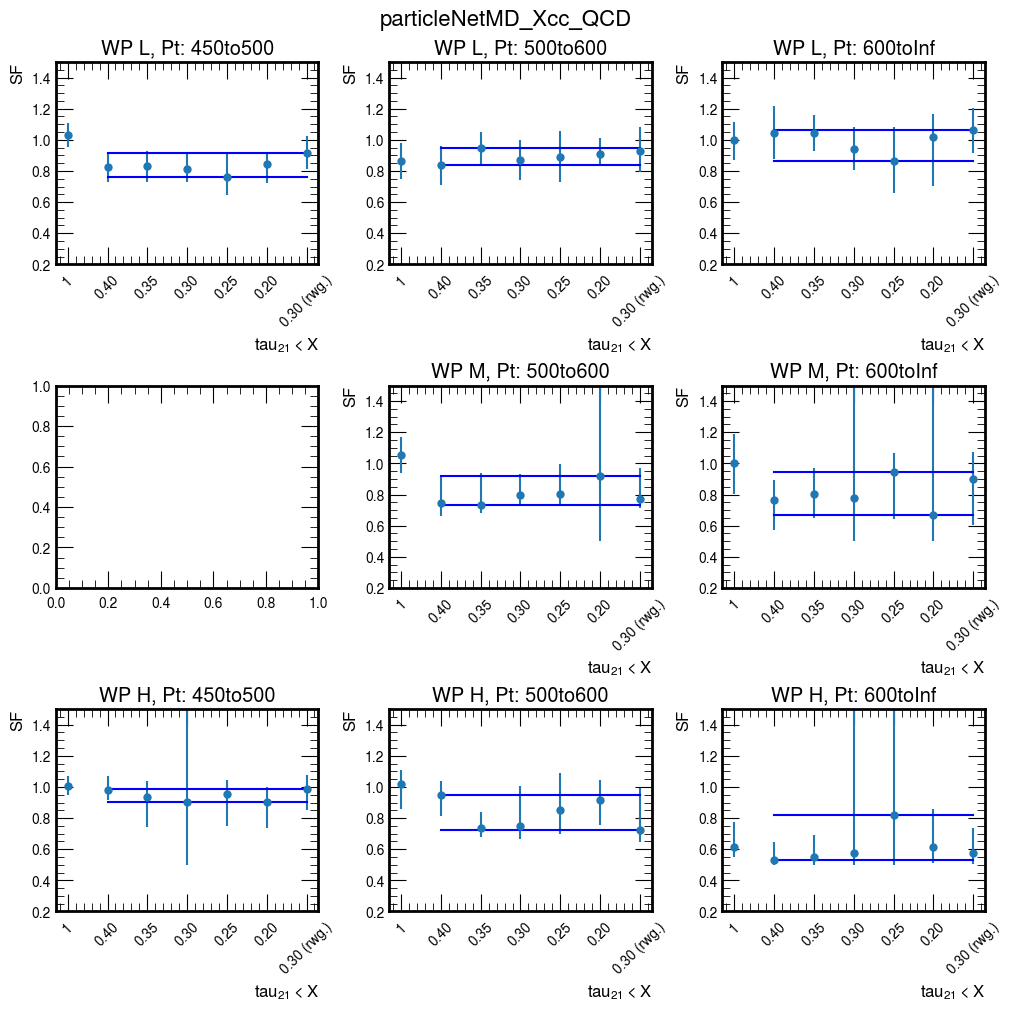

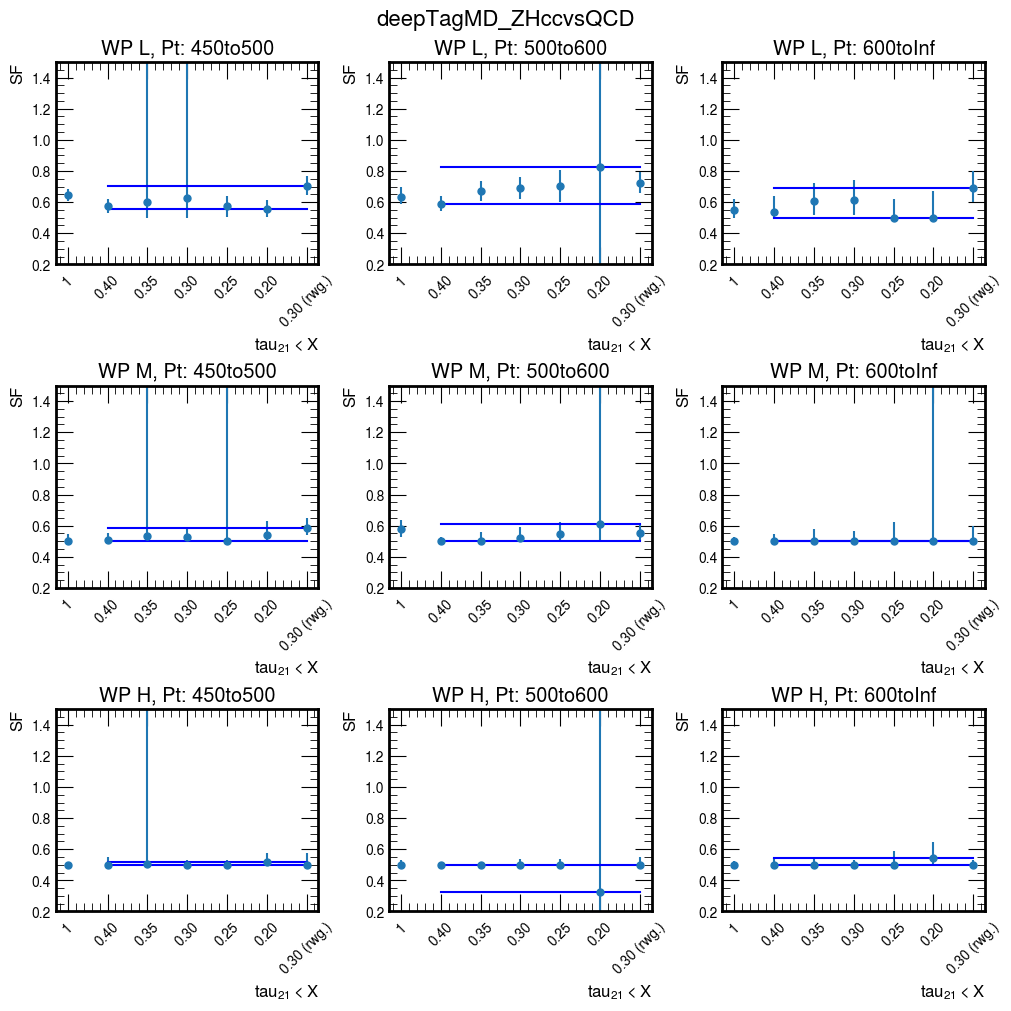

In [29]:
for tagger in AK8Taggers_cc:
    f, axs = plt.subplots(3,3,figsize=(10,10), constrained_layout=True, dpi=100)
    #plt.subplots_adjust(wspace=0.2, hspace=0.2)
    f.suptitle(tagger, fontsize=16)
    for ix, wp in enumerate(wps):
        for iy, pt in enumerate(pts):
            sfdata = sf_results[(sf_results.SF_flavour=="c")&\
                                (sf_results.tagger==tagger)&\
                                (sf_results.wp==wp)&\
                                (sf_results.pt==pt)]
            
            sf_max = sfdata[sfdata.tau21!=1].SF.max()
            sf_min = sfdata[sfdata.tau21!=1].SF.min()
            
            if len(sfdata)<7:
                print("missing fit")
                continue
                
            sf_rew = sfdata[sfdata.reweighed==1].SF.values[0]
            sf_rew_unc = abs(sfdata[sfdata.tau21=="0.30"].SF.values[0] - sf_rew)
                
            results_tau21_uncertainty.append({
                            "SF_flavour": "b",
                            "tagger": tagger,
                            "wp": wp,
                            "pt": pt,
                            "SF": sfdata[sfdata.tau21=="0.30"].SF.values[0],
                            "SF_errUp": sfdata[sfdata.tau21=="0.30"]["SF_errUp"].values[0],
                            "SF_errDown": sfdata[sfdata.tau21=="0.30"]["SF_errDown"].values[0],
                            "tau21_uncertainty": abs(sf_max-sf_min)/2,
                            "reweighting_uncertainty": sf_rew_unc,
                            })
            
            ax = axs[ix, iy]
            ax.set_title(f"WP {wp}, Pt: {pt}")
            ax.set_xlabel("$tau_{21}< X$")
            ax.set_ylabel("SF")
            #print(np.arange(5), sfdata.SF)
            #ax.errorbar(np.arange(7), sfdata.SF.values, yerr=[sfdata.SF_errDown.values, sfdata.SF_errUp.values]
            #            , linestyle='', marker='o', markersize=5, label=wp)
            ax.errorbar(np.arange(7), sfdata.SF.values, yerr=[sfdata.SF_errDown.values, abs(sfdata.SF_errUp.values)]
                        , linestyle='', marker='o', markersize=5, label=wp)
            ax.set_ylim(0.2, 1.5)
            xticklabels = list(map(str,sfdata.tau21.values))
            xticklabels[-1] = "0.30 (rwg.)"
            ax.set_xticks(np.arange(7), xticklabels, rotation=45)
            
            ax.plot([1., 6.], [sf_max,sf_max], "b-")
            ax.plot([1., 6.], [sf_min,sf_min], "b-")
    plt.savefig(f"results_2017_{tagger}.png", dpi=300, format="png")

In [14]:
results_tau21_uncertainty = pd.DataFrame(results_tau21_uncertainty)

In [15]:
results_tau21_uncertainty

,SF_flavour,tagger,wp,pt,SF,SF_errUp,SF_errDown,tau21_uncertainty,reweighting_uncertainty
0,b,btagDDBvLV2,L,450to500,0.903883,0.044346,3.789051e-02,0.054312,6.531640e-02
1,b,btagDDBvLV2,L,500to600,0.887150,0.040515,3.018817e-02,0.052588,6.952116e-02
2,b,btagDDBvLV2,L,600toInf,0.886690,0.011819,5.274584e-02,0.050565,3.871059e-02
3,b,btagDDBvLV2,M,450to500,0.970331,1.029669,4.703308e-01,0.060049,1.646506e-02
4,b,btagDDBvLV2,M,500to600,0.949053,0.045032,3.530306e-02,0.066437,3.974585e-02
...,...,...,...,...,...,...,...,...,...
56,b,deepTagMD_ZHccvsQCD,M,500to600,0.517932,0.076400,1.793118e-02,0.054721,3.388313e-02
57,b,deepTagMD_ZHccvsQCD,M,600toInf,0.500000,0.063002,2.589815e-07,0.000645,5.297650e-06
58,b,deepTagMD_ZHccvsQCD,H,450to500,0.500000,0.029564,3.347171e-08,0.008514,6.118341e-05
59,b,deepTagMD_ZHccvsQCD,H,500to600,0.500000,0.037600,1.443140e-09,0.086451,1.346253e-09


In [16]:
missing_fits

['/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017/fit_tau21p25_all_renormalized/results/fitResults_msd40particleNetMD_Xcc_QCDMwp_Pt-450to500.csv',
 '/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017/fit_tau21p25_all_renormalized/results/fitResults_msd40btagHbbMwp_Pt-600toInf.csv',
 '/work/mmarcheg/BTVNanoCommissioning/output/fit/approval/2017/fit_tau21p20_all_renormalized/results/fitResults_msd40btagHbbMwp_Pt-600toInf.csv']

In [42]:
len(missing_fits)

17